In [ ]:
!pip install ultralytics
!pip install deep-sort-realtime
!apt-get install ffmpeg

In [2]:
from google.colab import drive
drive.mount('/content/gdrive/')

Mounted at /content/gdrive/


In [39]:
import os
import random
import cv2
from ultralytics import YOLO
#from tracker import Tracker
from deep_sort_realtime.deepsort_tracker import DeepSort
from google.colab.patches import cv2_imshow
import matplotlib.pyplot as plt
import plotly.graph_objs as go
import plotly.express as px

In [4]:
model = YOLO('/content/gdrive/MyDrive/data/results_on_100_epochs/runs/detect/train/weights/best.pt')

In [5]:
tracker = DeepSort(max_age=20)

In [6]:
video_path = '/content/gdrive/MyDrive/data/videos/VID_20230716_200632.mp4'
video_path_out = '/content/gdrive/MyDrive/data/output_videos/VID_20230716_200632_track.avi'

In [ ]:
cap = cv2.VideoCapture(video_path)
fps = int(cap.get(cv2.CAP_PROP_FPS))
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

# For output video file
out = cv2.VideoWriter(video_path_out, cv2.VideoWriter_fourcc(*'XVID'), fps//2, (width, height))
detection_threshold = 0.3

track_history = {}

while True:
    ret, frame = cap.read()
    ret, frame = cap.read()
    if not ret:
        break

    results = model(frame)

    detections = []
    for result in results:
      for r in result.boxes.data.tolist():
        x1, y1, x2, y2, score, class_id = r
        x1, x2, y1, y2, class_id = int(x1), int(x2), int(y1), int(y2), int(class_id)
        if score > detection_threshold:
          detections.append(([x1, y1, x2-x1, y2-y1], score, class_id))

    tracks = tracker.update_tracks(detections, frame=frame)
    print(len(tracks))

    for track in tracks:
      track_id = track.track_id
      ltrb = track.to_ltrb()
      class_id = track.get_det_class()
      x1, y1, x2, y2 = map(int, ltrb)
      #print(x1, y1, x2, y2)

      cv2.rectangle(frame, (int(x1), int(y1)), (int(x2), int(y2)), (255, 0, 0), 2)
      cv2.putText(frame, str(track_id), (int(x1), int(y1) - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 2)

      if track_id not in track_history:
        track_history[track_id] = []

      center_x = int((x1 + x2) / 2)
      center_y = int((y1 + y2) / 2)
      track_history[track_id].append((center_x, center_y))

      for i in range(1, len(track_history[track_id])):
        cv2.line(frame, track_history[track_id][i - 1], track_history[track_id][i], (0, 255, 0), 2)


    cv2_imshow(frame)  # Display the frame in Colab
    cv2.waitKey(1)

    out.write(frame)
    ret, frame = cap.read()

cap.release()
out.release()
cv2.destroyAllWindows()

In [36]:
length_threshold = 50

filtered_track_history = {track_id: coords for track_id, coords in track_history.items() if len(coords) >= length_threshold}

# Plot

3-D Interactive plot

In [46]:
fig = go.Figure()

for track_id, coords in filtered_track_history.items():
    length_vals = [width - coord[0] for coord in coords]
    height_vals = [height - coord[1] for coord in coords]
    time_vals = list(range(1, len(coords) + 1))

    # Add a scatter plot trace for each track
    fig.add_trace(go.Scatter3d(
        x=length_vals, y=time_vals, z=height_vals,
        mode='lines+markers',
        marker=dict(size=5),
        line=dict(width=2),
        name=f'Track {track_id}'
    ))

# Set the title and axis labels
fig.update_layout(
    title='Object Tracks with Time Axis',
    scene=dict(
        xaxis_title='Width',
        yaxis_title='Time',
        zaxis_title='Height'
    ),
    width=1200,
    height=800
)

# Show the interactive plot
fig.show()

2-D simple plot

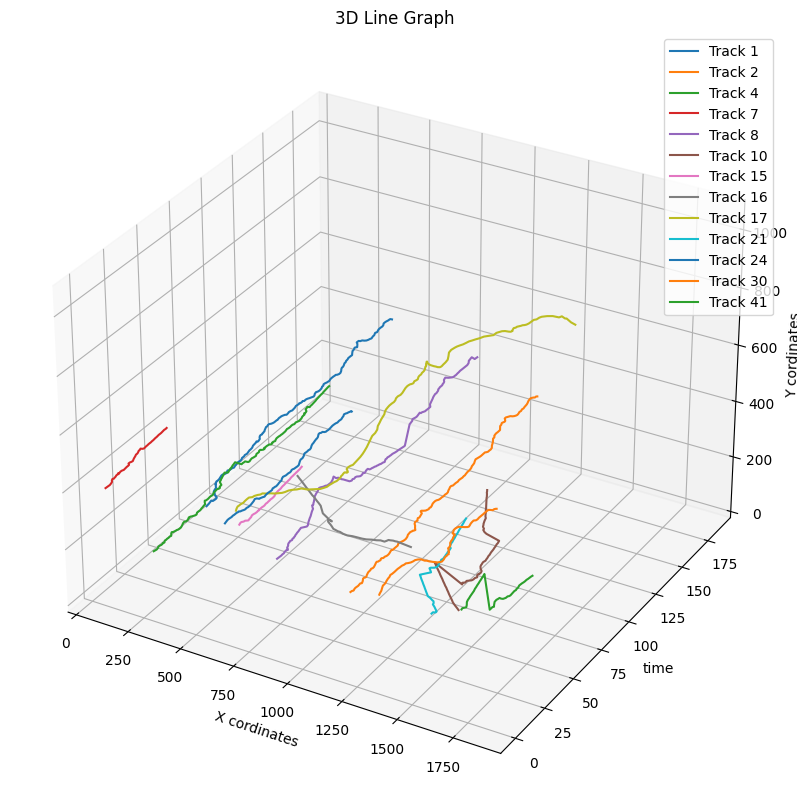

In [45]:
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')

for track_id, coords in filtered_track_history.items():
    length_vals = [width - coord[0] for coord in coords]
    height_vals = [height - coord[1] for coord in coords]
    time_vals = list(range(1, len(coords) + 1))

    ax.plot(length_vals, time_vals, height_vals, label = f'Track {track_id}')

ax.set_xlabel('X cordinates')
ax.set_ylabel('time')
ax.set_zlabel('Y cordinates')
ax.set_title('3D Line Graph')

ax.set_xlim(0, width)
#ax.set_ylim(0, len(time_vals))
ax.set_zlim(0, height)

ax.legend()

# Show the plot
plt.show()